# Consulta — Dados Enriquecidos C1

Exemplos de consultas ao dataframe enriquecido. Edite as variáveis/condições e rode a célula.

> Pré-requisito: rode `poetry run python scripts/enrich_dataframe.py` antes.

In [56]:
from pathlib import Path
import pandas as pd

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

ROOT = Path().resolve().parent
df = pd.read_csv(ROOT / 'data' / 'C1_enriquecido.csv')
print(f'{len(df)} linhas × {len(df.columns)} colunas')
df.columns.tolist()

2740 linhas × 22 colunas


['CÓDIGO',
 'REINO',
 'FILO',
 'CLASSE',
 'ORDEM',
 'FAMÍLIA',
 'GÊNERO',
 'ESPÉCIE',
 'ABUNDANCIA',
 'TIPO',
 'MÉTODO DE COLETA',
 'PONTO',
 'DATA',
 'CAMPANHA',
 'CORPO HÍDRICO AMOSTRADO',
 'LATITUDE',
 'LONGITUDE',
 'GRAU DE AMEAÇA',
 'ENDEMISMO',
 'IMPORTÂNCIA ECONOMICA ',
 'BIOMAS',
 'ENDEMICA_AMAZONIA']

## Resumo das colunas

In [57]:
pd.DataFrame({
    'preenchidas': df.notna().sum(),
    'vazias': df.isna().sum(),
    'únicas': df.nunique(dropna=True),
})

,preenchidas,vazias,únicas
CÓDIGO,2223,517,1682
REINO,2738,2,2
FILO,2738,2,4
CLASSE,2738,2,9
ORDEM,2738,2,43
FAMÍLIA,2740,0,105
GÊNERO,2731,9,225
ESPÉCIE,2740,0,357
ABUNDANCIA,2223,517,38
TIPO,2477,263,2


## Valores únicos de uma coluna

Use para descobrir quais valores existem antes de filtrar.

In [58]:
coluna = 'GRAU DE AMEAÇA'
df[coluna].value_counts(dropna=False)

GRAU DE AMEAÇA
LC                     2293
NE                      413
Dados insuficientes      33
Neoneura luzmarina        1
Name: count, dtype: int64

## Filtro por uma coluna

In [78]:
# Todas as linhas de uma família específica
sub = df[df['FAMÍLIA'] == 'Ochnaceae']
sub[['ESPÉCIE', 'GÊNERO', 'GRAU DE AMEAÇA', 'PONTO']].drop_duplicates()

,ESPÉCIE,GÊNERO,GRAU DE AMEAÇA,PONTO
2703,Sauvagesia erecta,Sauvagesia,LC,PB18
2704,Sauvagesia erecta,Sauvagesia,LC,PM31
2705,Sauvagesia erecta,Sauvagesia,LC,PB02
2706,Sauvagesia erecta,Sauvagesia,LC,PB20
2707,Sauvagesia erecta,Sauvagesia,LC,A1
2708,Sauvagesia erecta,Sauvagesia,LC,J3
2709,Sauvagesia erecta,Sauvagesia,LC,PM33
2710,Sauvagesia erecta,Sauvagesia,LC,PB22
2711,Sauvagesia erecta,Sauvagesia,LC,PM35
2712,Sauvagesia erecta,Sauvagesia,LC,PM36


## Filtro combinado (múltiplas condições)

In [60]:
# Plantas endêmicas no ponto T3
sub = df[
    (df['REINO'] == 'Plantae')
    & (df['ENDEMISMO'] == 'S')
    & (df['PONTO'] == 'T3')
]
sub[['ESPÉCIE', 'FAMÍLIA', 'GRAU DE AMEAÇA']].drop_duplicates()

,ESPÉCIE,FAMÍLIA,GRAU DE AMEAÇA


## Filtro por lista de valores (`isin`)

In [61]:
# Espécies em qualquer categoria de ameaça acima de LC
ameacas = ['NT', 'VU', 'EN', 'CR', 'DD']
sub = df[df['GRAU DE AMEAÇA'].isin(ameacas)]
sub[['ESPÉCIE', 'FAMÍLIA', 'REINO', 'GRAU DE AMEAÇA', 'PONTO']].drop_duplicates()

,ESPÉCIE,FAMÍLIA,REINO,GRAU DE AMEAÇA,PONTO


## Busca por substring no nome

In [62]:
# Case-insensitive, aceita parte do nome
busca = 'bryconops'
campo = 'ESPÉCIE'

sub = df[df[campo].astype(str).str.contains(busca, case=False, na=False)]
sub[['ESPÉCIE', 'FAMÍLIA', 'GRAU DE AMEAÇA', 'PONTO']].drop_duplicates()

,ESPÉCIE,FAMÍLIA,GRAU DE AMEAÇA,PONTO
2,Bryconops caudomaculatus,Iguanodectidae,LC,LB9
34,Bryconops caudomaculatus,Iguanodectidae,LC,LB4
95,Bryconops caudomaculatus,Iguanodectidae,LC,PM33
115,Bryconops sp.,Iguanodectidae,LC,PM33
149,Bryconops caudomaculatus,Iguanodectidae,LC,G3
271,Bryconops caudomaculatus,Iguanodectidae,LC,RQ3
319,Bryconops caudomaculatus,Iguanodectidae,LC,J2
372,Bryconops caudomaculatus,Iguanodectidae,LC,PB08
394,Bryconops caudomaculatus,Iguanodectidae,LC,L3
472,Bryconops caudomaculatus,Iguanodectidae,LC,A1


## Consulta com `.query()` (sintaxe SQL-like)

Atenção: `.query()` não aceita nomes com caracteres especiais (acentos, espaços) diretamente — use crase.

In [63]:
sub = df.query("REINO == 'Plantae' and `GRAU DE AMEAÇA` == 'LC'")
sub[['ESPÉCIE', 'FAMÍLIA', 'ENDEMISMO', 'PONTO']].drop_duplicates().head(20)

,ESPÉCIE,FAMÍLIA,ENDEMISMO,PONTO
2223,Justicia,Acanthaceae,N,T3
2224,Justicia laevilinguis,Acanthaceae,N,RQ3
2361,Cyperus brevifolius,Cyperaceae,N,A1
2362,Cyperus haspan,Cyperaceae,N,PM32
2363,Cyperus haspan,Cyperaceae,N,G3
2364,Cyperus haspan,Cyperaceae,N,A1
2365,Cyperus haspan,Cyperaceae,N,PC06
2366,Cyperus haspan,Cyperaceae,N,PM33
2367,Cyperus haspan,Cyperaceae,N,PB22
2368,Cyperus haspan,Cyperaceae,N,PM36


## Agrupar / agregar

In [64]:
# Riqueza por ponto e reino
riqueza = df.groupby(['PONTO', 'REINO'])['ESPÉCIE'].nunique().unstack(fill_value=0)
riqueza['TOTAL'] = riqueza.sum(axis=1)
riqueza.sort_values('TOTAL', ascending=False).head(15)

REINO,Animalia,Plantae,TOTAL
PONTO,,,
A1,40,28,68
F3,35,31,66
PM31,43,22,65
PB02,26,32,58
PM33,24,33,57
PM35,34,22,56
PB18,41,14,55
PB22,23,27,50
J3,33,17,50


In [65]:
# Espécies ocorrendo em mais pontos
por_especie = df.groupby('ESPÉCIE').agg(
    n_pontos=('PONTO', 'nunique'),
    pontos=('PONTO', lambda s: ', '.join(sorted(set(s.dropna().astype(str))))),
    familia=('FAMÍLIA', 'first'),
    ameaca=('GRAU DE AMEAÇA', 'first'),
).sort_values('n_pontos', ascending=False)
por_especie.head(20)

,n_pontos,pontos,familia,ameaca
ESPÉCIE,,,,
Hyphessobrycon heterorhabdus,27,"A1, F3, G3, J3, L3, LB4, LB6, M3, P3, PB02, PB...",Acestrorhamphidae,LC
Iguanodectes rachovii,22,"A1, F3, G3, J3, L3, LB6, M3, P3, PB02, PB05, P...",Iguanodectidae,LC
Stridulivelia alia,21,"F3, G3, J3, L3, LB6, M3, P3, PB05, PB06, PB08,...",Veliidae,LC
Rhagovelia brunae,21,"F3, G3, J2, J3, L3, LB4, M3, P3, PB05, PB06, P...",Veliidae,LC
Apistogramma geisleri,20,"A1, G3, J2, J3, LB4, LB6, M3, P3, PB05, PB18, ...",Cichlidae,LC
Urospatha sagittifolia,20,"A1, F3, G3, J2, J3, PB02, PB08, PB18, PB20, PB...",Araceae,NE
Laimosemion strigatum,20,"A1, LB4, LB5, LB6, M3, P3, PB05, PB06, PB18, P...",Rivulidae,LC
Stridulivelia strigosa,19,"A1, F3, J2, J3, LB4, LB6, M3, P3, PB02, PB05, ...",Veliidae,LC
Nymphaea rudgeana,19,"A1, F3, G3, L3, P03, PB02, PB08, PB20, PB5, PB...",Nymphaeaceae,NE


## Cruzar categorias (tabela dinâmica)

In [66]:
pd.crosstab(df['CLASSE'], df['GRAU DE AMEAÇA'], margins=True).sort_values('All', ascending=False)

GRAU DE AMEAÇA,Dados insuficientes,LC,NE,Neoneura luzmarina,All
CLASSE,,,,,
All,33,2293,411,1,2738
Insecta,33,1313,0,1,1347
Osteichthyes,0,859,0,0,859
Liliopsida,0,57,255,0,312
Magnoliopsida,0,47,122,0,169
Polypodiopsida,0,0,18,0,18
Lycopodiopsida,0,0,16,0,16
Malacostraca,0,14,0,0,14
Clitellata,0,2,0,0,2


## Taxonomia: família, gênero, espécie

Visualizações e tabelas dos três níveis taxonômicos. Edite as variáveis no topo de cada célula para ajustar quantos itens mostrar ou a família de interesse.

In [67]:
import matplotlib.pyplot as plt

# Totais em cada nível taxonômico
print(f'Famílias:  {df["FAMÍLIA"].nunique()} únicas')
print(f'Gêneros:   {df["GÊNERO"].nunique()} únicos')
print(f'Espécies:  {df["ESPÉCIE"].nunique()} únicas')

# Por reino
niveis = df.groupby('REINO').agg(
    familias=('FAMÍLIA', 'nunique'),
    generos=('GÊNERO', 'nunique'),
    especies=('ESPÉCIE', 'nunique'),
)
niveis

Famílias:  105 únicas
Gêneros:   225 únicos
Espécies:  357 únicas


,familias,generos,especies
REINO,,,
Animalia,62,150,223
Plantae,43,75,132


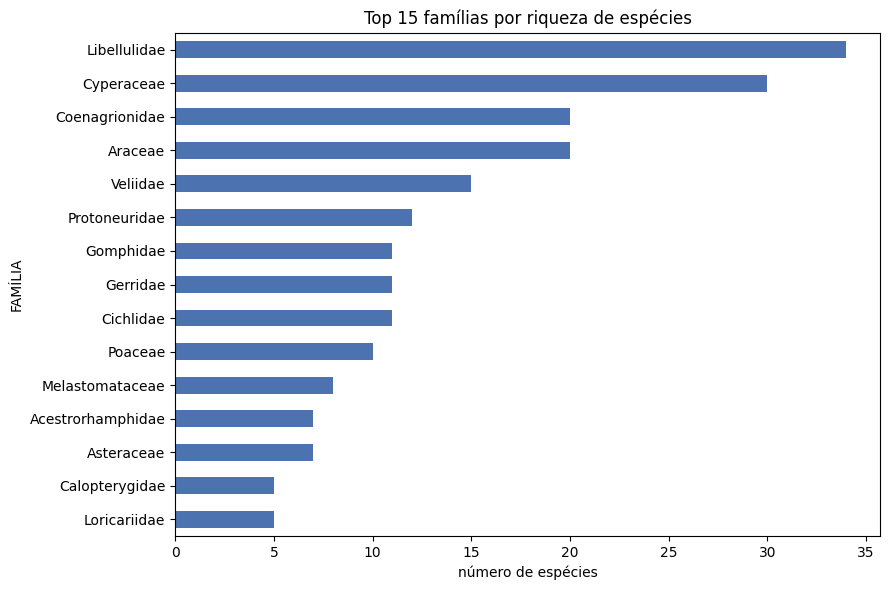

,espécies_únicas
FAMÍLIA,
Libellulidae,34
Cyperaceae,30
Coenagrionidae,20
Araceae,20
Veliidae,15
Protoneuridae,12
Gomphidae,11
Gerridae,11
Cichlidae,11


In [68]:
top_n = 15

# Top N famílias por número de espécies
fam = df.groupby('FAMÍLIA')['ESPÉCIE'].nunique().sort_values(ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
fam[::-1].plot.barh(ax=ax, color='#4C72B0')
ax.set_xlabel('número de espécies')
ax.set_title(f'Top {top_n} famílias por riqueza de espécies')
plt.tight_layout()
plt.show()

fam.to_frame('espécies_únicas')

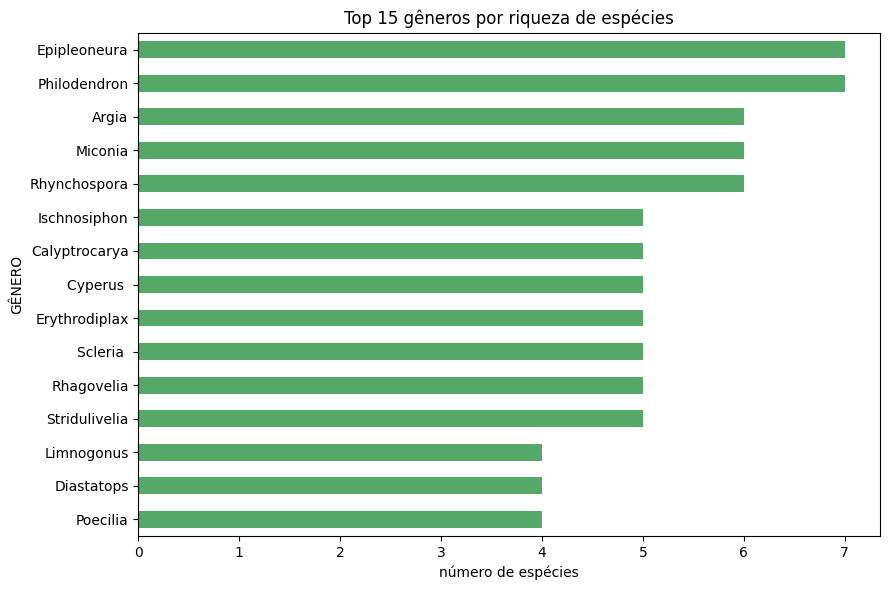

,espécies_únicas
GÊNERO,
Epipleoneura,7
Philodendron,7
Argia,6
Miconia,6
Rhynchospora,6
Ischnosiphon,5
Calyptrocarya,5
Cyperus,5
Erythrodiplax,5


In [69]:
top_n = 15

# Top N gêneros por número de espécies
gen = df.groupby('GÊNERO')['ESPÉCIE'].nunique().sort_values(ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
gen[::-1].plot.barh(ax=ax, color='#55A868')
ax.set_xlabel('número de espécies')
ax.set_title(f'Top {top_n} gêneros por riqueza de espécies')
plt.tight_layout()
plt.show()

gen.to_frame('espécies_únicas')

In [70]:
# Hierarquia Família → Gênero → Espécie (quantitativa)
hier = df.groupby(['FAMÍLIA', 'GÊNERO']).agg(
    n_especies=('ESPÉCIE', 'nunique'),
    especies=('ESPÉCIE', lambda s: ', '.join(sorted(set(s.dropna())))),
).sort_values('n_especies', ascending=False)

hier.head(20)

,,n_especies,especies
FAMÍLIA,GÊNERO,,
Araceae,Philodendron,7,"Philodendron, Philodendron , Philodendron brev..."
Coenagrionidae,Argia,6,"Argia collata, Argia fumigata, Argia indicatri..."
Cyperaceae,Rhynchospora,6,"Rhynchospora cephalotes, Rhynchospora corymbos..."
Melastomataceae,Miconia,6,"Clidemia hirta, Maieta guianensis, Maieta guia..."
Protoneuridae,Epipleoneura,6,"Epipleoneura sp., Epipleoneura capilliformis,..."
Cyperaceae,Calyptrocarya,5,"Calyptrocarya, Calyptrocarya bicolor, Calyptro..."
Libellulidae,Erythrodiplax,5,"Erythrodiplax basalis, Erythrodiplax cf. basal..."
Marantaceae,Ischnosiphon,5,"Ischnosiphon, Ischnosiphon arouma, Ischnosipho..."
Cyperaceae,Cyperus,5,"Cyperus brevifolius, Cyperus haspan, Cyperus l..."


In [71]:
# Drilldown: escolha uma família para ver seus gêneros e espécies
familia = 'Cichlidae'

sub = df[df['FAMÍLIA'] == familia]
print(f'Família: {familia}')
print(f'  {sub["GÊNERO"].nunique()} gêneros, {sub["ESPÉCIE"].nunique()} espécies, {len(sub)} registros')

sub.groupby('GÊNERO').agg(
    espécies=('ESPÉCIE', lambda s: ', '.join(sorted(set(s.dropna())))),
    n_espécies=('ESPÉCIE', 'nunique'),
    n_registros=('ESPÉCIE', 'size'),
).sort_values('n_espécies', ascending=False)

Família: Cichlidae
  8 gêneros, 11 espécies, 168 registros


,espécies,n_espécies,n_registros
GÊNERO,,,
Saxatilia,"Saxatilia lepidota, Saxatilia saxatilis, Saxat...",3,6
Apistogramma,"Apistogramma agassizii, Apistogramma geisleri",2,106
Aequidens,Aequidens tetramerus,1,36
Acaronia,Acaronia nassa,1,2
Caquetaia,Caquetaia spectabilis,1,8
Geophagus,Geophagus sp.,1,2
Heros,Heros sp.,1,1
Mesonauta,Mesonauta festivus,1,7


## Endemismo ao bioma Amazônia

A coluna `ENDEMICA_AMAZONIA` classifica cada espécie com base nos biomas de ocorrência segundo a Flora e Funga do Brasil:

- **`S`** — a espécie ocorre **apenas** no bioma Amazônia
- **`N`** — ocorre na Amazônia + outros biomas, OU só fora da Amazônia
- **`NaN`** — sem dado (animais e plantas não encontradas na Flora)

A coluna `BIOMAS` lista os biomas da Flora separados por `; `.

In [72]:
print('Distribuição geral:')
display(df['ENDEMICA_AMAZONIA'].value_counts(dropna=False).to_frame('linhas'))

print('\nPor reino:')
display(df.groupby(['REINO', 'ENDEMICA_AMAZONIA'], dropna=False).size().to_frame('linhas'))

Distribuição geral:


,linhas
ENDEMICA_AMAZONIA,
NaN,2296
N,368
S,76



Por reino:


linhas
REINO    ENDEMICA_AMAZONIA        
Animalia NaN                  2223
Plantae  N                     368
         S                      76
         NaN                    71
NaN      NaN                     2

In [73]:
# Espécies endêmicas do bioma Amazônia
sub = df[df['ENDEMICA_AMAZONIA'] == 'S']
print(f'{sub["ESPÉCIE"].nunique()} espécies endêmicas da Amazônia em {sub["PONTO"].nunique()} pontos')
sub[['ESPÉCIE', 'FAMÍLIA', 'BIOMAS', 'GRAU DE AMEAÇA', 'PONTO']].drop_duplicates(subset=['ESPÉCIE']).sort_values('FAMÍLIA')

24 espécies endêmicas da Amazônia em 30 pontos


,ESPÉCIE,FAMÍLIA,BIOMAS,GRAU DE AMEAÇA,PONTO
2225,Ruellia rubra,Acanthaceae,Amazônia,NE,PB02
2226,Dieffenbachia elegans,Araceae,Amazônia,NE,PB18
2239,Monstera dubia,Araceae,Amazônia,NE,A1
2240,Monstera spruceana,Araceae,Amazônia,NE,PB6
2278,Philodendron linnaei,Araceae,Amazônia,NE,U3
2282,Philodendron muricatum,Araceae,Amazônia,NE,PM02
2289,Spathiphyllum humboldtii,Araceae,Amazônia,NE,PB6
2437,Rhynchospora pubera,Cyperaceae,Amazônia,NE,PM31
2401,Diplasia karatifolia,Cyperaceae,Amazônia,NE,PM31
2423,Hypolytrum sylvaticum,Cyperaceae,Amazônia,NE,J2


In [74]:
# Espécies NÃO endêmicas da Amazônia (ocorrem também em outros biomas)
sub = df[df['ENDEMICA_AMAZONIA'] == 'S']
print(f'{sub["ESPÉCIE"].nunique()} espécies endêmicas')
sub[['ESPÉCIE', 'FAMÍLIA', 'BIOMAS']].drop_duplicates(subset=['ESPÉCIE']).sort_values('BIOMAS')

24 espécies endêmicas


,ESPÉCIE,FAMÍLIA,BIOMAS
2225,Ruellia rubra,Acanthaceae,Amazônia
2645,Ischnosiphon polyphyllus,Marantaceae,Amazônia
2644,Ischnosiphon obliquus,Marantaceae,Amazônia
2638,Ischnosiphon longiflorus,Marantaceae,Amazônia
2637,Ischnosiphon arouma,Marantaceae,Amazônia
2554,Paspalum scrobiculatum,Poaceae,Amazônia
2538,Pariana campestri,Poaceae,Amazônia
2517,Miconia racemosa,Melastomataceae,Amazônia
2502,Maieta guianensis,Melastomataceae,Amazônia
2497,Maieta guianensis,Melastomataceae,Amazônia


In [75]:
# Quantas endêmicas da Amazônia em cada ponto?
df.assign(endemica=df['ENDEMICA_AMAZONIA'] == 'S').groupby('PONTO').agg(
    endemicas_amazonia=('endemica', 'sum'),
    total_plantas=('REINO', lambda s: (s == 'Plantae').sum()),
).sort_values('endemicas_amazonia', ascending=False).head(15)

,endemicas_amazonia,total_plantas
PONTO,,
A1,5,28
PB27,5,13
PM33,4,33
U3,4,9
PB02,4,32
M3,4,13
RQ3,4,23
PC02,4,14
PM31,4,22


In [76]:
# Famílias com mais espécies endêmicas da Amazônia
df[df['ENDEMICA_AMAZONIA'] == 'S'].groupby('FAMÍLIA')['ESPÉCIE'].nunique().sort_values(ascending=False).head(10).to_frame('espécies_endêmicas')

,espécies_endêmicas
FAMÍLIA,
Araceae,6
Cyperaceae,6
Marantaceae,4
Melastomataceae,3
Poaceae,2
Selaginellaceae,2
Acanthaceae,1


## Exportar resultado

In [77]:
sub.to_csv(ROOT / 'data' / 'consulta_resultado.csv', index=False)
print(f'Salvo em data/consulta_resultado.csv ({len(sub)} linhas)')

Salvo em data/consulta_resultado.csv (76 linhas)
